In [1]:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np
from math import ceil

from firedrake.petsc import PETSc
import petsc4py

from time import perf_counter

### User defined operators compatible with PETSc KSP solver.
For further info:

https://www.firedrakeproject.org/petsc-interface.html

and the documentation of firedrake and PETSc/petsc4py.

---
---
# Exercise 1
## Solve steady Stokes problem by Schur-complement method.

### Cavity problem

\begin{equation*}
\begin{cases}
- \Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega=(0,1)^2, \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = \boldsymbol{g}_\text{D} & {\rm on} \ \Gamma_4 = (0,1)\times\{4\},\\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \partial\Omega\setminus\Gamma_4,
\end{cases}
\end{equation*}

with $\boldsymbol{g}_\text{D} = 1\boldsymbol{i}$.

In [3]:
# We use the GLOBAL PETSc options, stored in the following global variable.
# This variable is modified by Firedrake when we set the solver parameters
# by, e.g.,     LinearVariationalSolver(..., solver_parameters=...)
petsc_options = PETSc.Options()

For each point of the exercise we create functions, so that it is easier to re-use code.

### Point 1. Assemble the matrices defining the problem

In [4]:
def ex1_problem_assemble(n):
    # Mesh, FE spaces (separate, not mixed), and trial and test functions.
    mesh = UnitSquareMesh(n, n, 'crossed')
    V = VectorFunctionSpace(mesh, 'P', 2)
    Q = FunctionSpace(mesh, 'P', 1)
    u = TrialFunction(V)
    v = TestFunction(V)
    p = TrialFunction(Q)
    q = TestFunction(Q)

    # Data.
    g_lid = Constant((1.0,0.0))

    # Variational forms with the penalty method for Dirichlet boundary conditions.
    eps = 1e-20
    a = inner(grad(u), grad(v)) * dx \
        + (1.0/eps)*inner(u,v)*ds           # fully Dirichlet: integral on the whole boundary
    minusb = div(u) * q * dx         # implementing -B
    bt = - div(v) * p * dx      # implementing +B^T
    L = inner(Constant((0.0,0.0)), v) * dx \
        + (1.0/eps)*inner(g_lid,v)*ds(4)    # Dirichlet conditions are non-homogeneous only on boundary 4

    # Assemble monolithic system
    # "MAT=assemble(FORM)" yields a Firedrake matrix. To extract its PETSc representation, we use "MAT.M.handle".
    A = assemble(a).M.handle
    minusB = assemble(minusb).M.handle
    Bt = assemble(bt).M.handle
    F = assemble(L)

    # Define a solver for A: needed to assemble the rhs of the Schur system and to reconstruct velocity.
    # We modify and use the global PETSc options to tell PETSc how this solver should be set up.
    ksp_A = PETSc.KSP().create()
    ksp_A.setOperators(A)
    petsc_options['ksp_type'] = 'gmres'
    petsc_options['pc_type'] = 'ilu'
    ksp_A.setFromOptions()
    ksp_A.setUp()

    return V, Q, A, minusB, Bt, F, ksp_A

### Point 2. Define classes for Schur complement and M-based preconditioner.

In [5]:
def define_stokes_schur_solver(A, asB, Bt, pc_S_form):
    # Inputs:   A, asB, Bt  blocks of the monolithic matrix
    #           pc_S_form   preconditioner for the Schur complement S
    # Output:   S           the Schur complement S=-(asB*A^-1*Bt)
    # Notice: asB can be either B or -B: the resulting S will have a different sign
    print('SIZES:', A.size, Bt.size, asB.size)
    if (asB - PETSc.Mat().createTranspose(Bt)).norm() < 1e-15:
        print('\tBlock-symm formulation: [A, Bt, B, 0] -> S = -(B*A^-1*Bt)')
    elif (asB + PETSc.Mat().createTranspose(Bt)).norm() < 1e-15:
        print('\tBlock-skew formulation: [A, Bt, -B, 0] -> S = B*A^-1*Bt')
    else:
        print('\tWARNING - Re-check def of asB, Bt', (asB - PETSc.Mat().createTranspose(Bt)).norm(), (asB + PETSc.Mat().createTranspose(Bt)).norm())

    # Define Schur complement S.
    # Syntax: S = PETSc.Mat().createSchurComplement(A00, pc_A00, A01, A10, A11)
    # NB1: does not actually perform "A^-1": it sets up the system so that it can represent the application of S
    # NB2: as a preconditioner for A within the definition of S, we use A itself  <->  direct solver for A^-1 in the definition
    # NB3: the problem we are interested in has A11=0 -> use None
    S = PETSc.Mat().createSchurComplement( A, A, Bt, asB, None )

    # ADVANCED FEATURES to inspect the lowest level of the algebraic structures.
    # ksp_A sets options also on A.
    # If different options ought to be set in A to be used within S,
    # they should be set here, through S.
    tmp_ksp = petsc_options['ksp_type']
    tmp_pc = petsc_options['pc_type']
    petsc_options['ksp_type'] = 'preonly'
    petsc_options['pc_type'] = 'lu'
    S.setFromOptions()
    petsc_options['ksp_type'] = tmp_ksp
    petsc_options['pc_type'] = tmp_pc

    # Define a solver for the Schur complement, with the mass matrix as a preconditioner.
    # Use the global variable petsc_options to setup the solver.

    # ksp_S.setOperators(S)     # ERROR: schurcomplement matrices are not actually assembled, therefore a preconditioner MUST be provided
    #                           # and it must be provided EXPLICITLY:
    #                           # petsc_options['schur_pc_type'] = 'lu'     -> still ERROR: impossible to factorize a matrix that is not assembled

    # Setup the preconditioner (comment/uncomment lines to change preconditioner)
    ones_vec = PETSc.Vec().createWithArray(np.ones(S.size[0])) # useful below...

    # # no preconditioner -> identity matrix
    # pc_S_mat = PETSc.Mat().createDiagonal(ones_vec)

    # The following preconditioners are all constructed based on MM
    MM = assemble(pc_S_form).M.handle

    # # pressure mass matrix
    # pc_S_mat = MM

    # # diagonal of the pressure mass matrix
    # pc_S_mat = PETSc.Mat().createDiagonal(MM.getDiagonal())

    # lumped pressure mass matrix
    lumped_vec = MM.createVecRight()
    MM.mult(ones_vec, lumped_vec)
    pc_S_mat = PETSc.Mat().createDiagonal(lumped_vec)

    # We know that S "has a nullspace" spanned by constant functions
    # (or at least that its eigenvalue along this space is on the order of eps).
    # Skipping this setting actually provides the same results in this specific exercise,
    # yet it is better to keep aware of this possible issue.
    nsp = PETSc.NullSpace().create(constant=True)
    S.setNullSpace(nsp) # set nullspace of S before passing it to ksp_S

    # Now we can actually create and setup the solver for S.
    ksp_S = PETSc.KSP().create()
    ksp_S.setOptionsPrefix('schur_')
    petsc_options['schur_ksp_type'] = 'cg'  # works on a positive definite matrix.....but also on a negative-definite one!
    petsc_options['schur_pc_type'] = 'mat'  # use the preconditioner matrix passed by setOperators
    ksp_S.setOperators(S, pc_S_mat)
    ksp_S.setFromOptions()
    ksp_S.setUp()

    return S, ksp_S

### Point 3. Solve Stokes cavity problem.

In [7]:
def solve_problem(V, Q, ksp_A, asB, Bt, F, ksp_S):
    # Notice: asB can be either B or -B, as long as the sign of S is in accordance with it.

    # Solve the problem
    uh = Function(V)
    ph = Function(Q)
    tmp_u_fun = Function(V)
    tmp_p_fun = Function(Q)
    rhs_p_fun = Function(Q)
    # Extract the dof vectors as PETSc.Vec and give them aliases.
    # Temporary vectors are in read/write mode,
    # while momentum rhs is in read-only mode.
    with uh.dat.vec_wo as vecU,\
        ph.dat.vec_wo as vecP,\
        F.dat.vec_ro as vecF,\
        tmp_u_fun.dat.vec_wo as tmp_u,\
        tmp_p_fun.dat.vec_wo as tmp_p,\
        rhs_p_fun.dat.vec_wo as rhs_p:

        # rhs_p = -asB*(A^{-1}*F)
        print("##### ASSEMBLING RHS ...", flush=True)
        ksp_A.solve(-vecF, tmp_u)  # see https://petsc.org/release/petsc4py/reference/petsc4py.PETSc.KSP.html#petsc4py.PETSc.KSP.solve
        asB.mult(tmp_u, rhs_p)    # see https://petsc.org/release/petsc4py/reference/petsc4py.PETSc.Mat.html#petsc4py.PETSc.Mat.mult
        print("##### ... COMPLETED ASSEMBLING RHS (", ksp_A.getIterationNumber(), "iter for A^-1)", flush=True)

        # solve S*P = rhs_p and store it into the dof array of ph
        print("##### SOLVING SCHUR ...", flush=True)
        start_time = perf_counter()
        ksp_S.solve(rhs_p, vecP)
        elapsed_time = perf_counter() - start_time
        print("##### ... COMPLETED SOLVING SCHUR (", ksp_S.getIterationNumber(), "iter for S^-1, in", elapsed_time, "s)", flush=True)

        # reconstruct velocity U = A^{-1}*(F-B'*P) and store it into the dof array of uh
        print("##### VELOCITY RECONSTRUCTION ...", flush=True)
        Bt.mult(vecP, tmp_u)
        tmp_u = vecF - tmp_u
        ksp_A.solve(tmp_u, vecU)
        print("##### ... COMPLETED VELOCITY RECONSTRUCTION (", ksp_A.getIterationNumber(), "iter for A^-1)", flush=True)

    return uh, ph

In [8]:
# Set verbose to True for detailed logging of ksp's.
verbose = False
if verbose:
    petsc_options['ksp_view'] = ''
    petsc_options['ksp_monitor'] = ''
    # petsc_options['ksp_monitor_true_residual'] = ''   # too much information: activate it only when necessary
    petsc_options['schur_ksp_view'] = ''
    petsc_options['schur_ksp_monitor'] = ''
    # petsc_options['schur_ksp_monitor_true_residual'] = ''   # too much information: activate it only when necessary
else:
    del petsc_options['ksp_view']
    del petsc_options['ksp_monitor']
    del petsc_options['ksp_monitor_true_residual']
    del petsc_options['schur_ksp_view']
    del petsc_options['schur_ksp_monitor']
    del petsc_options['schur_ksp_monitor_true_residual']

V, Q, A, minusB, Bt, F, ksp_A = ex1_problem_assemble(10)

p = TrialFunction(Q)
q = TestFunction(Q)
pc_form = p*q*dx
S, ksp_S = define_stokes_schur_solver(A, minusB, Bt, pc_form)

# Print all set options.
petsc_options.view()

# Solve problem
uh, ph = solve_problem(V, Q, ksp_A, minusB, Bt, F, ksp_S)

SIZES: (882, 882) (882, 121) (121, 882)
	Block-skew formulation: [A, Bt, -B, 0] -> S = B*A^-1*Bt
#PETSc Option Table entries:
-f /home/aless/.local/share/jupyter/runtime/kernel-7fc8979b-79ce-401b-a16d-904cf4b15bd4.json # (source: command line)
-ksp_type gmres # (source: code)
-pc_type ilu # (source: code)
-schur_ksp_type cg # (source: code)
-schur_pc_type mat # (source: code)
#End of PETSc Option Table entries
##### ASSEMBLING RHS ...
##### ... COMPLETED ASSEMBLING RHS ( 11 iter for A^-1)
##### SOLVING SCHUR ...
##### ... COMPLETED SOLVING SCHUR ( 18 iter for S^-1, in 0.006450746004702523 s)
##### VELOCITY RECONSTRUCTION ...
##### ... COMPLETED VELOCITY RECONSTRUCTION ( 12 iter for A^-1)


Text(0.5, 1.0, 'velocity')

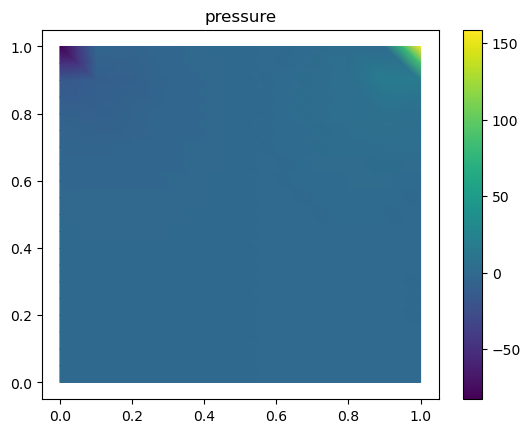

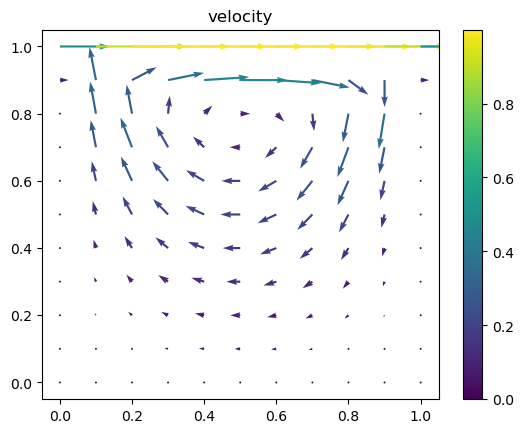

In [9]:
# Plot ph and uh
fig, ax = plt.subplots()
col = tripcolor(ph, axes=ax)
plt.colorbar(col)
plt.title('pressure')
fig, ax = plt.subplots()
col = quiver(uh, axes=ax)
plt.colorbar(col)
plt.title('velocity')

---
---
# Exercise 2
## Solve unsteady Stokes problem by Schur-complement method and implicit Euler scheme.

### Unsteady cavity problem

\begin{equation*}
\begin{cases}
\frac{\partial\boldsymbol{u}}{\partial t} - \Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega=(0,1)^2
\quad\forall t\in(0,1), \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega
\quad\forall t\in(0,1), \\
\boldsymbol{u} = \boldsymbol{g}_\text{D} & {\rm on} \ \Gamma_4 = (0,1)\times\{4\}
\quad\forall t\in(0,1), \\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \partial\Omega\setminus\Gamma_4
\quad\forall t\in(0,1), \\
\boldsymbol{u} = \boldsymbol{0} & {\rm in} \ \Omega,
\quad{\rm for} \ t=0,
\end{cases}
\end{equation*}

with $\boldsymbol{g}_\text{D}(t,\boldsymbol{x}) = t\boldsymbol{i}$.


For the definition of the problem, variational forms, matrices, preconditioners, we use what has been already computed in Exercise 1, therefore **run** the cells of Exercise 1 before running the following ones.

In [10]:
def ex2_problem_assemble(n, dt):
    # Algebraic system at each time step is
    # [ (M+A)*U + B'*P = M*Uold + F
    #   -B*U = 0 ]

    V, Q, A, minusB, Bt, F, ksp_A = ex1_problem_assemble(n)
    u = TrialFunction(V)
    v = TestFunction(V)
    M = assemble(Constant(1.0/dt) * inner(u, v) * dx).M.handle
    # Note: since we are using the penalty method to enforce Dirichlet BCs, we do not need to apply BCs to the matrix M.

    # Data.
    g_lid = Constant((1.0,0.0))

    # Define a new KSP solver associated to (M+A).
    ksp_MA = PETSc.KSP().create()
    ksp_MA.setType('preonly')   # direct solver
    ksp_MA.pc.setType('lu')
    ksp_MA.setOperators(M+A)
    ksp_MA.setFromOptions()
    ksp_MA.setUp()

    return V, Q, M, A, minusB, Bt, F, ksp_MA

t = 0  :  ||u||_{L^2} = 0.0
SIZES: (882, 882) (882, 121) (121, 882)
	Block-skew formulation: [A, Bt, -B, 0] -> S = B*A^-1*Bt
##### ASSEMBLING RHS ...
##### ... COMPLETED ASSEMBLING RHS ( 6 iter for A^-1)
##### SOLVING SCHUR ...
##### ... COMPLETED SOLVING SCHUR ( 18 iter for S^-1, in 0.023586162002175115 s)
##### VELOCITY RECONSTRUCTION ...
##### ... COMPLETED VELOCITY RECONSTRUCTION ( 6 iter for A^-1)
t = 0.01  :  ||u||_{L^2} = 0.0019006041140694906
##### ASSEMBLING RHS ...
##### ... COMPLETED ASSEMBLING RHS ( 6 iter for A^-1)
##### SOLVING SCHUR ...
##### ... COMPLETED SOLVING SCHUR ( 18 iter for S^-1, in 0.0013619070014101453 s)
##### VELOCITY RECONSTRUCTION ...
##### ... COMPLETED VELOCITY RECONSTRUCTION ( 6 iter for A^-1)
t = 0.02  :  ||u||_{L^2} = 0.004116185817401467
##### ASSEMBLING RHS ...
##### ... COMPLETED ASSEMBLING RHS ( 6 iter for A^-1)
##### SOLVING SCHUR ...
##### ... COMPLETED SOLVING SCHUR ( 18 iter for S^-1, in 0.001335533001110889 s)
##### VELOCITY RECONSTRUCTION .

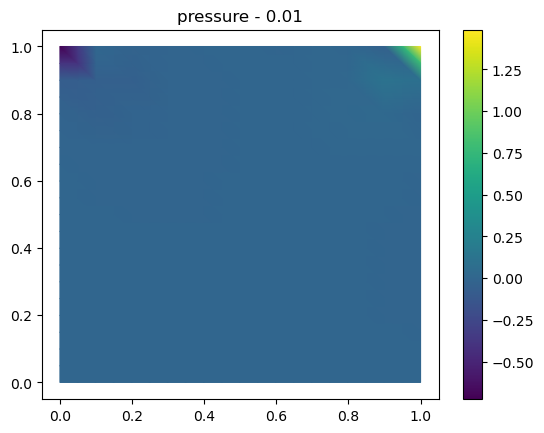

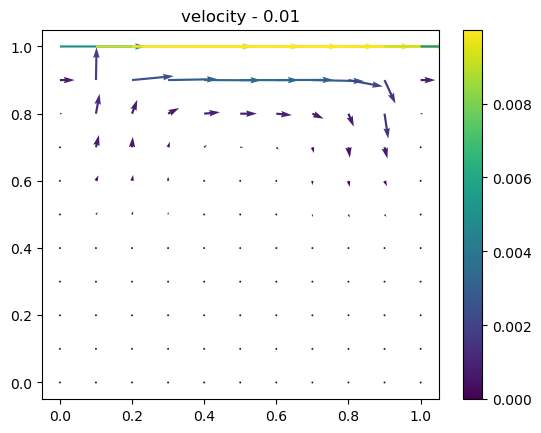

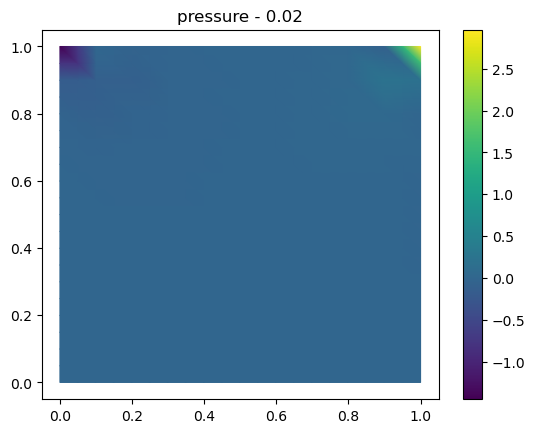

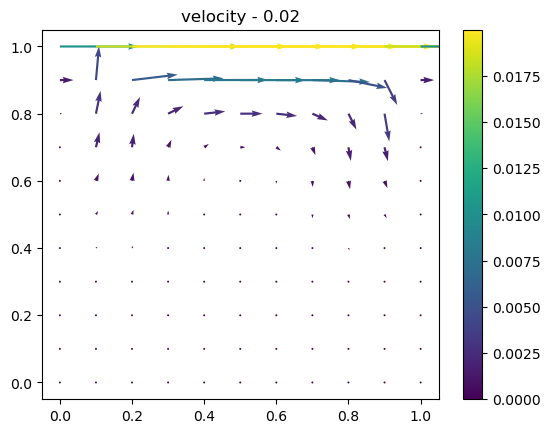

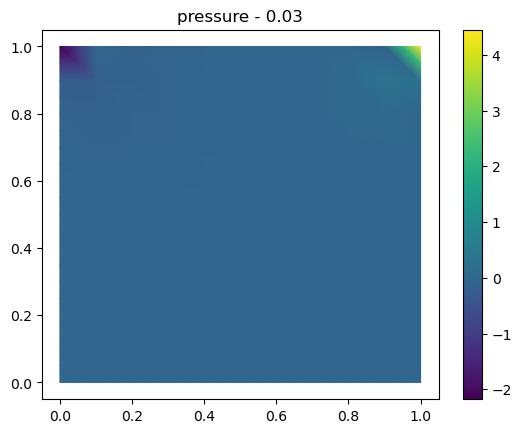

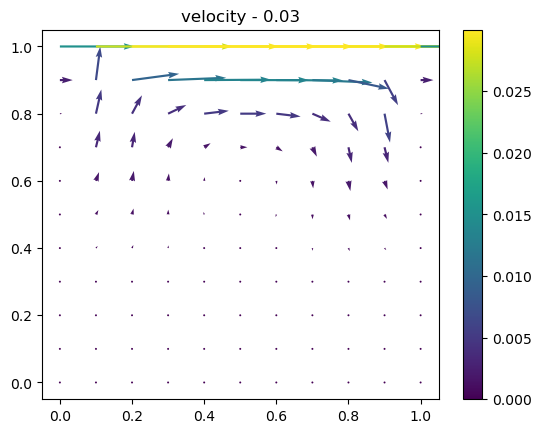

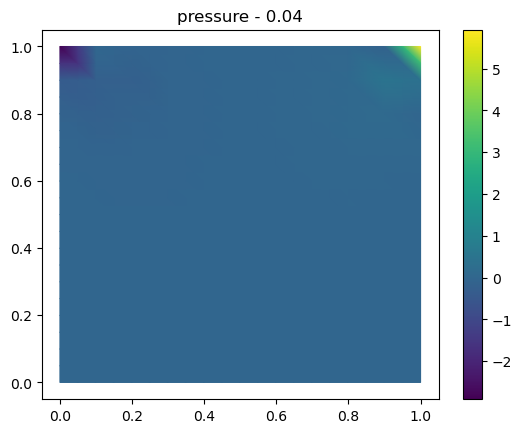

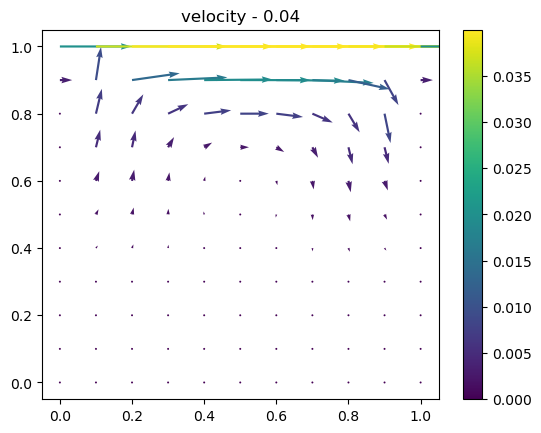

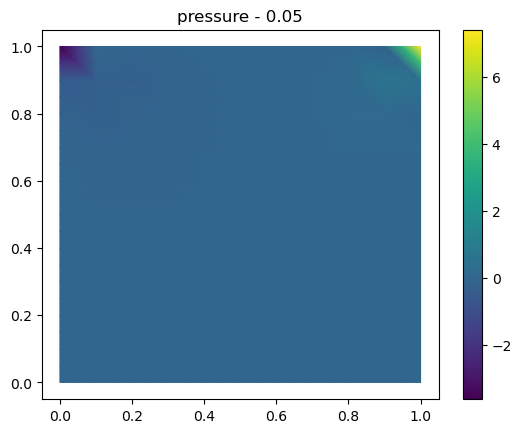

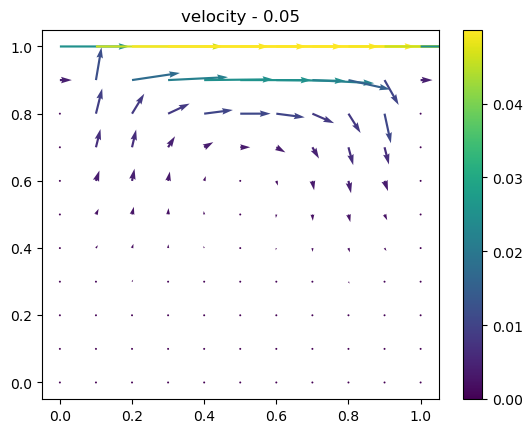

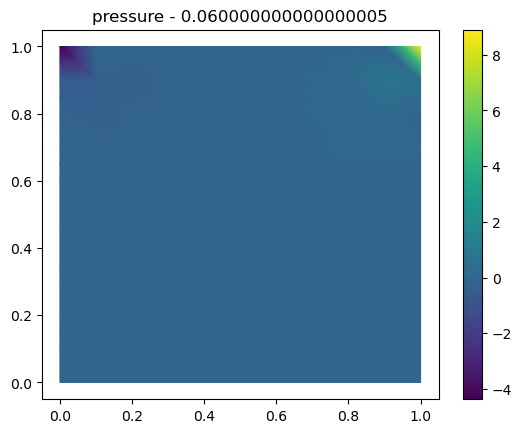

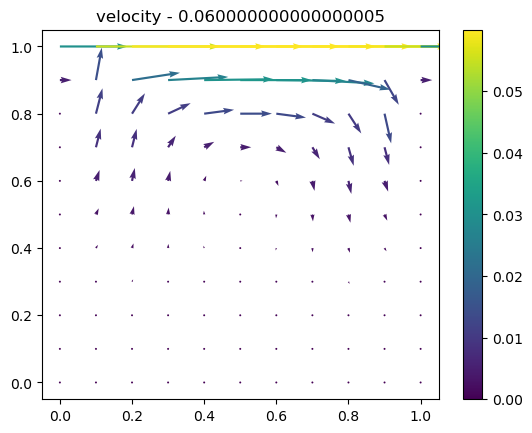

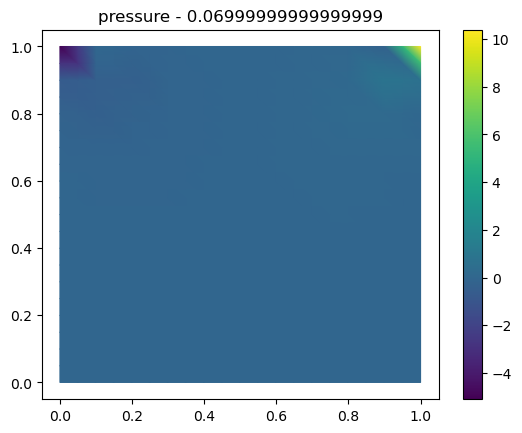

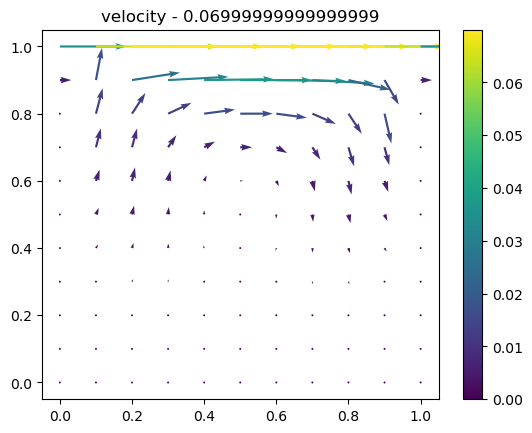

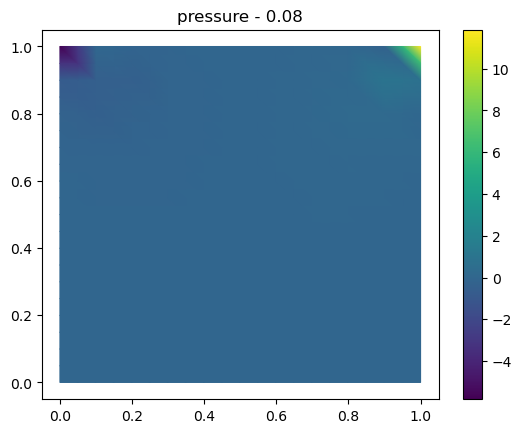

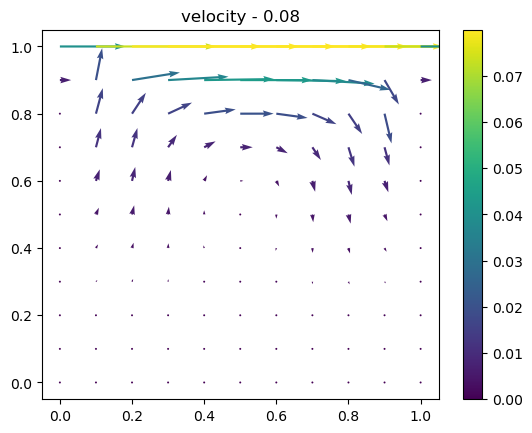

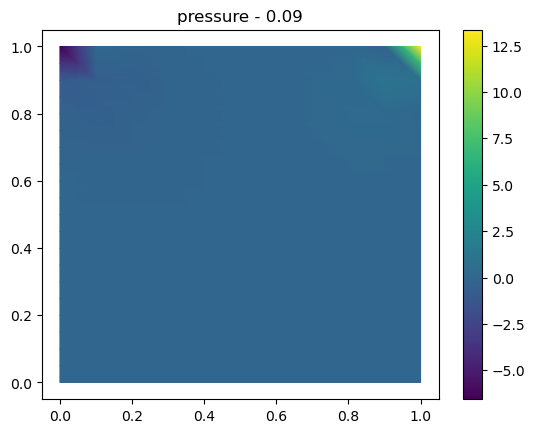

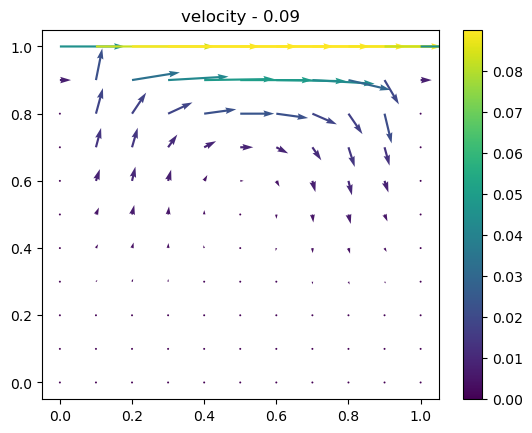

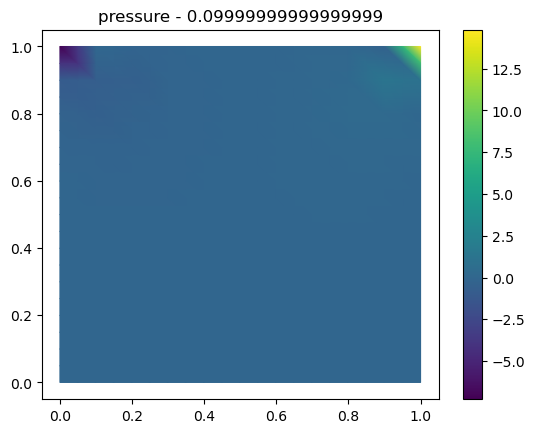

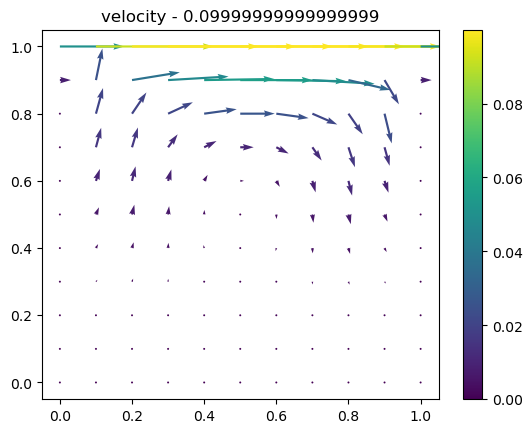

In [14]:
# Time parameters and initial condition.
t0 = 0
T = 0.1
dt = 0.01
u0 = Function(V)    # We need the old solution to be a Function, since we need its dof vector to proceed algebraically
u0.interpolate(Constant((0., 0.)))
print('t =', t0, ' :  ||u||_{L^2} =', norm(u0,'L2'))

# Create the Schur complement.
V, Q, M, A, minusB, Bt, F, ksp_MA = ex2_problem_assemble(10, dt)

p = TrialFunction(Q)
q = TestFunction(Q)
pc_form = p*q*dx
S, ksp_S = define_stokes_schur_solver(A, minusB, Bt, pc_form)

# Solve time-dependent problem.
tmp_u_fun = Function(V)
rhs_u_fun = Function(V)
for t in dt+np.arange(t0, T, dt):
    with u0.dat.vec_wo as vecUold,\
        F.dat.vec_ro as vecF,\
        tmp_u_fun.dat.vec_wo as tmp_u,\
        rhs_u_fun.dat.vec_wo as rhs:
        # Assemble the current rhs of the system.
        vecF.copy(tmp_u)                # NB NOT tmp_u = vecF (would perform only shallow copy, i.e. reference to same object)
        tmp_u *= t
        M.multAdd(vecUold, tmp_u, rhs)  # rhs = M*vecUold + tmp_u

    # Advance in time: solve the problem with M+A in place of A
    uh, ph = solve_problem(V, Q, ksp_MA, minusB, Bt, rhs_u_fun, ksp_S)
    print('t =', t, ' :  ||u||_{L^2} =', norm(uh,'L2'))

    fig, ax = plt.subplots()
    col = tripcolor(ph, axes=ax)
    plt.colorbar(col)
    plt.title('pressure - '+str(t))
    fig, ax = plt.subplots()
    #triplot(mesh, axes=ax)
    col = quiver(uh, axes=ax)
    plt.colorbar(col)
    plt.title('velocity - '+str(t))

    u0 = uh # update the old solution